[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Mounted at /content/drive
Original shapes:
Train: (560000, 2)
Test : (38000, 2)

After cleaning:
Full dataset shape: (597994, 4)

=== DATASET OVERVIEW ===


,Metric,Value
0,Total Samples,597994
1,Training Samples,559994
2,Testing Samples,38000
3,Number of Classes,2
4,Negative Reviews,298997
5,Positive Reviews,298997
6,Missing Text Values,0
7,Duplicate Text Rows,16


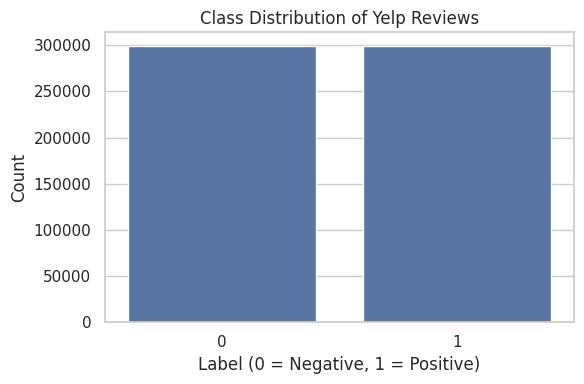

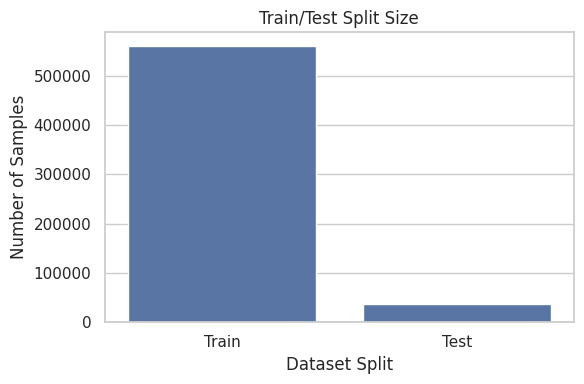


=== TEXT STRUCTURE STATISTICS ===


,Metric,Value
0,Average Word Count per Document,153.18
1,Average Sentence Count per Document,8.51
2,Minimum Word Count,1.00
3,Maximum Word Count,1213.00
4,Average Character Count per Document,722.61
5,Average Sentence Length (words),18.39


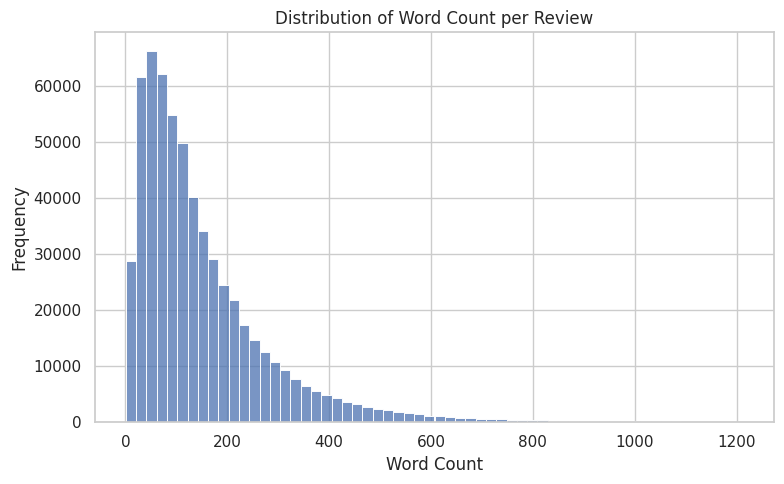

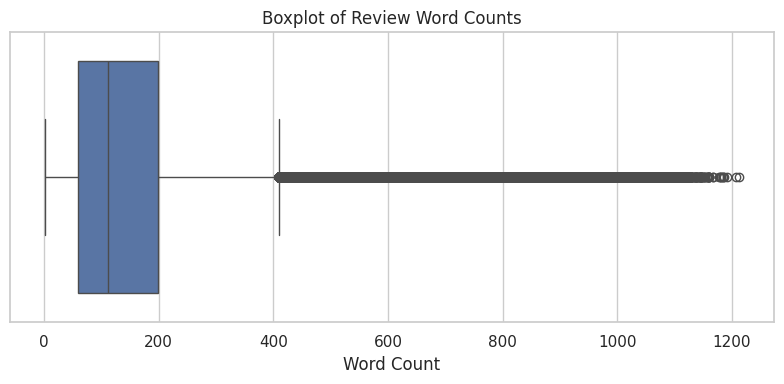

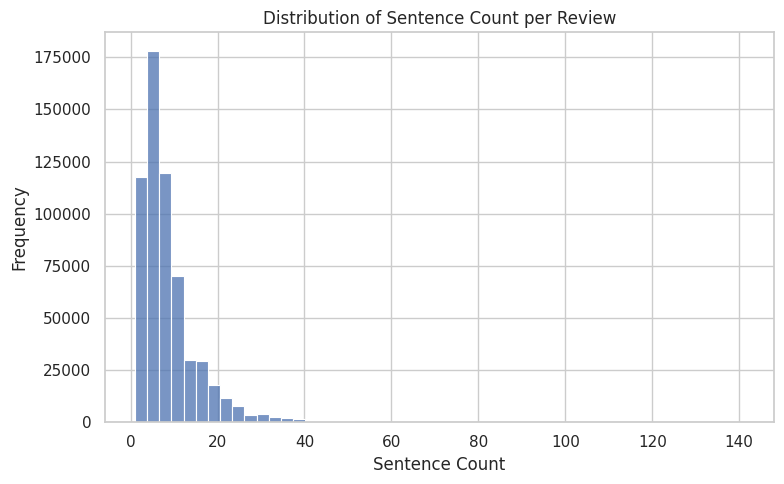

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1019 > 512). Running this sequence through the model will result in indexing errors



=== TOKEN STATISTICS ===


,Metric,Value
0,Average Token Count,178.25
1,Median Token Count,129.0
2,Minimum Token Count,3
3,Maximum Token Count,2068
4,Reviews > 128 Tokens,300264 (50.21%)
5,Reviews > 256 Tokens,127368 (21.30%)
6,Reviews > 512 Tokens,27630 (4.62%)


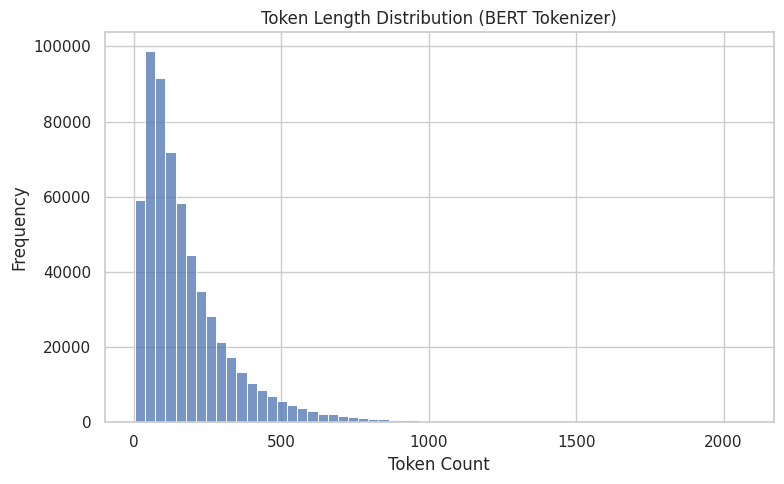

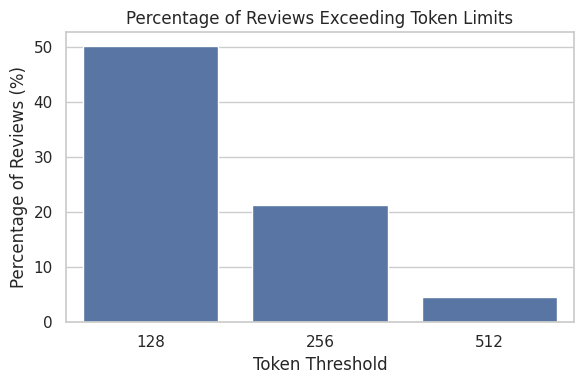


=== VOCABULARY STATISTICS ===


,Metric,Value
0,Vocabulary Size,184983



=== TOP 20 POSITIVE WORDS ===


,word,frequency
0,good,175066
1,place,166178
2,great,166003
3,food,145586
4,like,115672
5,one,102152
6,get,102011
7,time,95995
8,really,89481
9,service,85987



=== TOP 20 NEGATIVE WORDS ===


,word,frequency
0,food,198665
1,place,173942
2,would,168265
3,like,162149
4,get,150385
5,one,147112
6,good,137814
7,service,131094
8,time,129533
9,back,127924


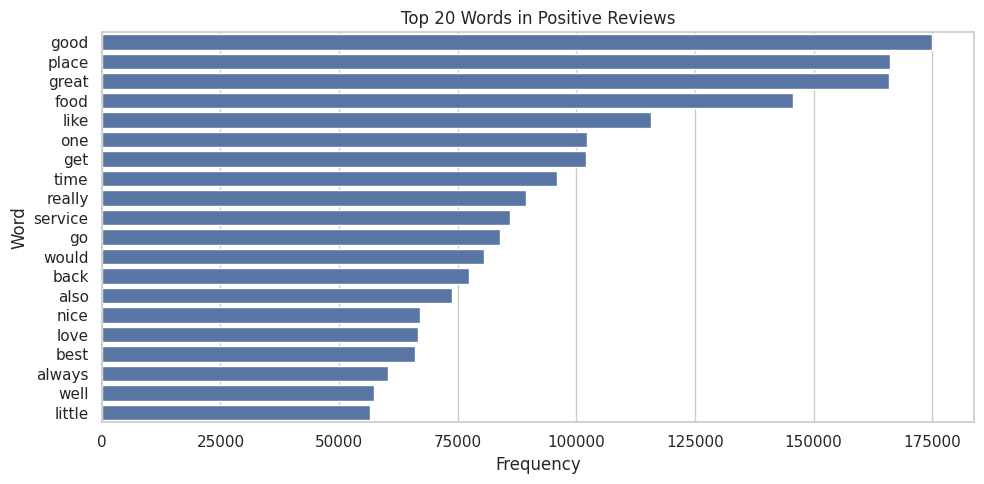

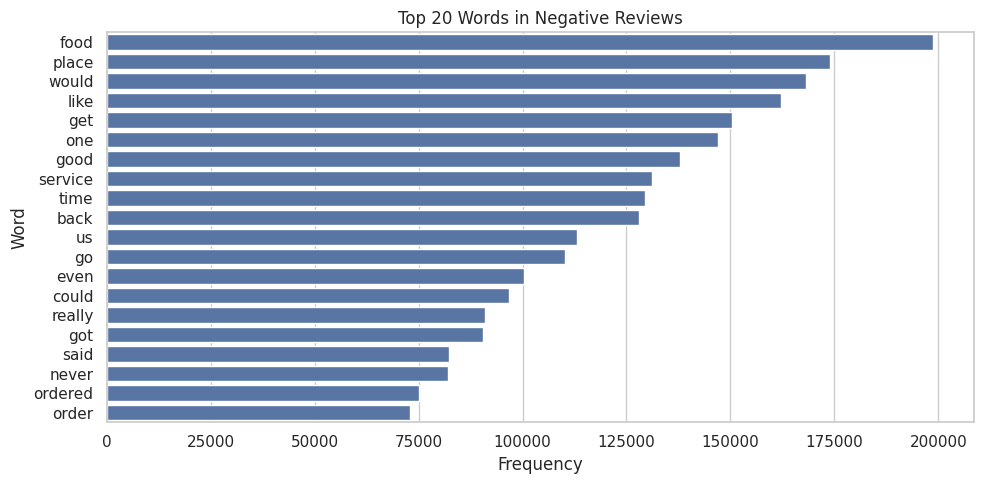

In [ ]:
# =====================================================
# YELP REVIEW POLARITY - THESIS-READY EDA
# JUPYTER / COLAB FRIENDLY
# Includes:
# 1. Dataset overview
# 2. Train/test split
# 3. Class distribution
# 4. Word count statistics
# 5. Sentence count statistics
# 6. Document length distribution
# 7. Token length distribution (BERT tokenizer)
# 8. % documents exceeding token limits
# 9. Vocabulary size
# 10. Average sentence length
# 11. Top positive / negative words
# 12. Positive / negative word clouds
# =====================================================

# !pip install -q pandas numpy matplotlib seaborn nltk scikit-learn transformers wordcloud

import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

from transformers import AutoTokenizer

import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

sns.set(style="whitegrid")

# =====================================================
# 1. PATHS
# =====================================================
from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH = "/content/drive/MyDrive/yelp_review_polarity_csv/train.csv"
TEST_PATH  = "/content/drive/MyDrive/yelp_review_polarity_csv/test.csv"
OUTPUT_DIR = "/content/drive/MyDrive/yelp_eda_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =====================================================
# 2. LOAD DATA
# =====================================================
train_df = pd.read_csv(TRAIN_PATH, header=None, names=["label", "text"])
test_df = pd.read_csv(TEST_PATH, header=None, names=["label", "text"])

print("Original shapes:")
print("Train:", train_df.shape)
print("Test :", test_df.shape)

# Yelp labels are 1 and 2 -> convert to 0 and 1
label_map = {1: 0, 2: 1}
train_df["label"] = train_df["label"].map(label_map)
test_df["label"] = test_df["label"].map(label_map)

train_df["split"] = "train"
test_df["split"] = "test"

df = pd.concat([train_df, test_df], ignore_index=True)

# =====================================================
# 3. CLEAN TEXT
# =====================================================
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("<br />", " ")
    text = text.replace("\n", " ")
    text = text.replace("\t", " ")
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].astype(str).apply(clean_text)

# remove empty rows if any
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

print("\nAfter cleaning:")
print("Full dataset shape:", df.shape)

# =====================================================
# 4. BASIC DATASET OVERVIEW
# =====================================================
total_samples = len(df)
train_samples = (df["split"] == "train").sum()
test_samples = (df["split"] == "test").sum()

class_counts = df["label"].value_counts().sort_index()
negative_count = class_counts.get(0, 0)
positive_count = class_counts.get(1, 0)

overview_table = pd.DataFrame({
    "Metric": [
        "Total Samples",
        "Training Samples",
        "Testing Samples",
        "Number of Classes",
        "Negative Reviews",
        "Positive Reviews",
        "Missing Text Values",
        "Duplicate Text Rows"
    ],
    "Value": [
        total_samples,
        train_samples,
        test_samples,
        df["label"].nunique(),
        negative_count,
        positive_count,
        df["clean_text"].isna().sum(),
        df["clean_text"].duplicated().sum()
    ]
})

print("\n=== DATASET OVERVIEW ===")
display(overview_table)

overview_table.to_csv(os.path.join(OUTPUT_DIR, "dataset_overview.csv"), index=False)

# =====================================================
# 5. CLASS DISTRIBUTION / SPLIT DISTRIBUTION
# =====================================================
plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df)
plt.title("Class Distribution of Yelp Reviews")
plt.xlabel("Label (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"), dpi=300)
plt.show()

split_table = pd.DataFrame({
    "Split": ["Train", "Test"],
    "Samples": [train_samples, test_samples]
})

plt.figure(figsize=(6, 4))
sns.barplot(x="Split", y="Samples", data=split_table)
plt.title("Train/Test Split Size")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "train_test_split.png"), dpi=300)
plt.show()

# =====================================================
# 6. TEXT STRUCTURE METRICS
# =====================================================
df["word_count"] = df["clean_text"].apply(lambda x: len(word_tokenize(x)))
df["sentence_count"] = df["clean_text"].apply(lambda x: len(sent_tokenize(x)))
df["char_count"] = df["clean_text"].apply(len)

def avg_sentence_length_words(text):
    sents = sent_tokenize(text)
    if len(sents) == 0:
        return 0
    sent_lengths = [len(word_tokenize(s)) for s in sents]
    return np.mean(sent_lengths)

df["avg_sentence_length_words"] = df["clean_text"].apply(avg_sentence_length_words)

length_stats = pd.DataFrame({
    "Metric": [
        "Average Word Count per Document",
        "Average Sentence Count per Document",
        "Minimum Word Count",
        "Maximum Word Count",
        "Average Character Count per Document",
        "Average Sentence Length (words)"
    ],
    "Value": [
        round(df["word_count"].mean(), 2),
        round(df["sentence_count"].mean(), 2),
        int(df["word_count"].min()),
        int(df["word_count"].max()),
        round(df["char_count"].mean(), 2),
        round(df["avg_sentence_length_words"].mean(), 2)
    ]
})

print("\n=== TEXT STRUCTURE STATISTICS ===")
display(length_stats)

length_stats.to_csv(os.path.join(OUTPUT_DIR, "text_structure_stats.csv"), index=False)

# =====================================================
# 7. WORD COUNT DISTRIBUTION
# =====================================================
plt.figure(figsize=(8, 5))
sns.histplot(df["word_count"], bins=60)
plt.title("Distribution of Word Count per Review")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "word_count_distribution.png"), dpi=300)
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=df["word_count"])
plt.title("Boxplot of Review Word Counts")
plt.xlabel("Word Count")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "word_count_boxplot.png"), dpi=300)
plt.show()

# =====================================================
# 8. SENTENCE COUNT DISTRIBUTION
# =====================================================
plt.figure(figsize=(8, 5))
sns.histplot(df["sentence_count"], bins=50)
plt.title("Distribution of Sentence Count per Review")
plt.xlabel("Sentence Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sentence_count_distribution.png"), dpi=300)
plt.show()

# =====================================================
# 9. TOKEN LENGTH DISTRIBUTION (BERT TOKENIZER)
# =====================================================
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def get_token_count(text):
    return len(tokenizer.encode(text, add_special_tokens=True, truncation=False))

# sample-safe option for large dataset if needed
# for full dataset keep as below
df["token_count"] = df["clean_text"].apply(get_token_count)

token_stats_table = pd.DataFrame({
    "Metric": [
        "Average Token Count",
        "Median Token Count",
        "Minimum Token Count",
        "Maximum Token Count",
        "Reviews > 128 Tokens",
        "Reviews > 256 Tokens",
        "Reviews > 512 Tokens"
    ],
    "Value": [
        round(df["token_count"].mean(), 2),
        round(df["token_count"].median(), 2),
        int(df["token_count"].min()),
        int(df["token_count"].max()),
        f"{(df['token_count'] > 128).sum()} ({((df['token_count'] > 128).mean()*100):.2f}%)",
        f"{(df['token_count'] > 256).sum()} ({((df['token_count'] > 256).mean()*100):.2f}%)",
        f"{(df['token_count'] > 512).sum()} ({((df['token_count'] > 512).mean()*100):.2f}%)"
    ]
})

print("\n=== TOKEN STATISTICS ===")
display(token_stats_table)

token_stats_table.to_csv(os.path.join(OUTPUT_DIR, "token_stats.csv"), index=False)

plt.figure(figsize=(8, 5))
sns.histplot(df["token_count"], bins=60)
plt.title("Token Length Distribution (BERT Tokenizer)")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "token_length_distribution.png"), dpi=300)
plt.show()

threshold_df = pd.DataFrame({
    "Threshold": ["128", "256", "512"],
    "Percentage Exceeding": [
        (df["token_count"] > 128).mean() * 100,
        (df["token_count"] > 256).mean() * 100,
        (df["token_count"] > 512).mean() * 100
    ]
})

plt.figure(figsize=(6, 4))
sns.barplot(x="Threshold", y="Percentage Exceeding", data=threshold_df)
plt.title("Percentage of Reviews Exceeding Token Limits")
plt.xlabel("Token Threshold")
plt.ylabel("Percentage of Reviews (%)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "token_threshold_exceeding.png"), dpi=300)
plt.show()

# =====================================================
# 10. VOCABULARY SIZE
# =====================================================
stop_words = set(stopwords.words("english"))

def tokenize_for_vocab(text):
    words = word_tokenize(text.lower())
    words = [w for w in words if w.isalpha()]
    return words

all_tokens = []
for text in df["clean_text"]:
    all_tokens.extend(tokenize_for_vocab(text))

vocab = set(all_tokens)
vocab_size = len(vocab)

vocab_table = pd.DataFrame({
    "Metric": ["Vocabulary Size"],
    "Value": [vocab_size]
})

print("\n=== VOCABULARY STATISTICS ===")
display(vocab_table)

vocab_table.to_csv(os.path.join(OUTPUT_DIR, "vocabulary_stats.csv"), index=False)

# =====================================================
# 11. TOP POSITIVE / NEGATIVE WORDS
# =====================================================
def get_top_words(text_series, top_n=20):
    tokens = []
    for text in text_series:
        words = tokenize_for_vocab(text)
        words = [w for w in words if w not in stop_words]
        tokens.extend(words)
    counter = Counter(tokens)
    return pd.DataFrame(counter.most_common(top_n), columns=["word", "frequency"])

pos_df = get_top_words(df[df["label"] == 1]["clean_text"], top_n=20)
neg_df = get_top_words(df[df["label"] == 0]["clean_text"], top_n=20)

print("\n=== TOP 20 POSITIVE WORDS ===")
display(pos_df)

print("\n=== TOP 20 NEGATIVE WORDS ===")
display(neg_df)

pos_df.to_csv(os.path.join(OUTPUT_DIR, "top_positive_words.csv"), index=False)
neg_df.to_csv(os.path.join(OUTPUT_DIR, "top_negative_words.csv"), index=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="frequency", y="word", data=pos_df)
plt.title("Top 20 Words in Positive Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_positive_words.png"), dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x="frequency", y="word", data=neg_df)
plt.title("Top 20 Words in Negative Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_negative_words.png"), dpi=300)
plt.show()

# =====================================================
# 12. WORD CLOUDS
# =====================================================
def build_wordcloud(text_series, title, save_name):
    tokens = []
    for text in text_series:
        words = tokenize_for_vocab(text)
        words = [w for w in words if w not in stop_words]
        tokens.extend(words)

    text_for_wc = " ".join(tokens)

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=200
    ).generate(text_for_wc)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=300)
    plt.show()

build_wordcloud(df[df["label"] == 1]["clean_text"], "Word Cloud - Positive Reviews", "positive_wordcloud.png")
build_wordcloud(df[df["label"] == 0]["clean_text"], "Word Cloud - Negative Reviews", "negative_wordcloud.png")

# =====================================================
# 13. FINAL SUMMARY TABLE
# =====================================================
final_summary = pd.DataFrame({
    "Metric": [
        "Total Samples",
        "Training Samples",
        "Testing Samples",
        "Negative Reviews",
        "Positive Reviews",
        "Average Word Count",
        "Average Sentence Count",
        "Minimum Word Count",
        "Maximum Word Count",
        "Average Token Count",
        "Reviews > 256 Tokens",
        "Reviews > 512 Tokens",
        "Vocabulary Size",
        "Average Sentence Length (words)"
    ],
    "Value": [
        total_samples,
        train_samples,
        test_samples,
        negative_count,
        positive_count,
        round(df["word_count"].mean(), 2),
        round(df["sentence_count"].mean(), 2),
        int(df["word_count"].min()),
        int(df["word_count"].max()),
        round(df["token_count"].mean(), 2),
        f"{(df['token_count'] > 256).sum()} ({((df['token_count'] > 256).mean()*100):.2f}%)",
        f"{(df['token_count'] > 512).sum()} ({((df['token_count'] > 512).mean()*100):.2f}%)",
        vocab_size,
        round(df["avg_sentence_length_words"].mean(), 2)
    ]
})

print("\n=== FINAL EDA SUMMARY ===")
display(final_summary)

final_summary.to_csv(os.path.join(OUTPUT_DIR, "final_eda_summary.csv"), index=False)

print(f"\nAll EDA outputs saved in: {OUTPUT_DIR}")